In [ ]:
#@title Importación de librerías

# Manejo de rutas y memoria caché
from pathlib import Path
from joblib import Memory

# Manipulación y visualización de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from IPython.display import display

# Preprocesamiento
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier

# Balanceo y pipeline
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline

# Validación y búsqueda de hiperparámetros
from sklearn.model_selection import GridSearchCV, ParameterGrid

# Métricas
from sklearn.metrics import (
    make_scorer,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve
)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


# 🔰 Problemática 1

**🚩 Problema predictivo 1: Regresión — Estimar la demanda mensual futura de cada producto según el canal de venta, la campaña comercial, el periodo y el comportamiento histórico de la demanda y los descuentos.**

Predicción de la cantidad de unidades demandadas por producto, categoría, subcategoría, marca, canal y campaña comercial.

**Pregunta de negocio:**

¿Cuántas unidades de cada producto se espera vender durante una campaña comercial determinada, en un mes y canal de venta específicos?

**Por ejemplo:**

¿Cuántas unidades del producto X se venderán por Web durante Cyber Wow Abril?

¿Cuál será la demanda del producto Y por App durante Navidad?

¿Cuántas unidades se espera vender en el canal Tienda durante un periodo normal de julio?

**Objetivo general**

Desarrollar y evaluar modelos predictivos de regresión que permitan estimar la cantidad de unidades demandadas de cada producto por campaña comercial, mes y canal de venta, utilizando las características del producto y el comportamiento histórico de la demanda y los descuentos.

**Variable objetivo:**

Demanda, medida como la cantidad total de unidades vendidas.

## 🚩 Carga y búsqueda de valores faltantes

In [5]:
#@title Carga de CSV desde la carpeta datos

from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

# Directorio desde donde se está ejecutando el notebook
DIRECTORIO_ACTUAL = Path.cwd()

# Detectar automáticamente la carpeta datos
if (DIRECTORIO_ACTUAL / "datos").exists():
    # El notebook se ejecuta desde proyecto-andinaretail
    RUTA_DATOS = DIRECTORIO_ACTUAL / "datos"

elif (DIRECTORIO_ACTUAL.parent / "datos").exists():
    # El notebook se ejecuta desde proyecto-andinaretail/notebooks
    RUTA_DATOS = DIRECTORIO_ACTUAL.parent / "datos"

else:
    raise FileNotFoundError(
        "No se encontró la carpeta 'datos'. "
        f"Directorio actual: {DIRECTORIO_ACTUAL}"
    )

# Rutas de archivos
ruta_ventas = RUTA_DATOS / "ventas.csv"
ruta_productos = RUTA_DATOS / "productos.csv"
ruta_tiendas = RUTA_DATOS / "tiendas.csv"
ruta_tickets = RUTA_DATOS / "tickets.csv"
ruta_clientes = RUTA_DATOS / "clientes.csv"
ruta_inventario = RUTA_DATOS / "inventario.csv"

# Carga de CSV
df_ventas = pd.read_csv(ruta_ventas, encoding="utf-8")
df_productos = pd.read_csv(ruta_productos, encoding="utf-8")
df_tiendas = pd.read_csv(ruta_tiendas, encoding="utf-8")
df_tickets = pd.read_csv(ruta_tickets, encoding="utf-8")
df_clientes = pd.read_csv(ruta_clientes, encoding="utf-8")
df_inventario = pd.read_csv(ruta_inventario, encoding="utf-8")

print("\nArchivos cargados correctamente.\n")

print("df_ventas:", df_ventas.shape)
print("df_productos:", df_productos.shape)
print("df_tiendas:", df_tiendas.shape)
print("df_tickets:", df_tickets.shape)
print("df_clientes:", df_clientes.shape)
print("df_inventario:", df_inventario.shape)


Archivos cargados correctamente.

df_ventas: (264967, 18)
df_productos: (1000, 8)
df_tiendas: (12, 7)
df_tickets: (100000, 14)
df_clientes: (15000, 15)
df_inventario: (432000, 9)


In [ ]:
#@title Información general de cada DataFrame
# Diccionario con todos los datasets cargados
datasets = {
    "Ventas": df_ventas,
    "Productos": df_productos,
    "Clientes": df_clientes,
    "Inventario": df_inventario,
    "Tickets": df_tickets,
    "Tiendas":df_tiendas,

}


for nombre, df in datasets.items():
    print("=" * 70)
    print(f"DATOS: {nombre.upper()}")
    print("=" * 70)
    df.info()
    print("\n")

DATOS: VENTAS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264967 entries, 0 to 264966
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id_venta         264967 non-null  int64  
 1   id_ticket        264967 non-null  object 
 2   fecha            264967 non-null  object 
 3   id_cliente       264967 non-null  int64  
 4   id_tienda        264967 non-null  int64  
 5   id_producto      264967 non-null  int64  
 6   cantidad         264967 non-null  int64  
 7   precio_unitario  264967 non-null  float64
 8   descuento_pct    261787 non-null  float64
 9   costo_unitario   264967 non-null  float64
 10  monto_total      264967 non-null  float64
 11  margen_unitario  264967 non-null  float64
 12  margen_total     264967 non-null  float64
 13  canal            264967 non-null  object 
 14  metodo_pago      260957 non-null  object 
 15  campaña          264967 non-null  object 
 16  es_campaña       264967 

In [ ]:
#@title Años que abarca el dataset de ventas

import pandas as pd

# Convertir la columna fecha a tipo datetime
df_ventas["fecha"] = pd.to_datetime(
    df_ventas["fecha"],
    errors="coerce"
)

# Obtener año mínimo y máximo
anio_inicio = df_ventas["fecha"].dt.year.min()
anio_fin = df_ventas["fecha"].dt.year.max()

print("Año inicial:", anio_inicio)
print("Año final:", anio_fin)
print(f"El dataset abarca desde {anio_inicio} hasta {anio_fin}.")

# Mostrar los años disponibles
print("\nAños presentes en el dataset:")
print(sorted(df_ventas["fecha"].dt.year.dropna().unique()))

Año inicial: 2023
Año final: 2025
El dataset abarca desde 2023 hasta 2025.

Años presentes en el dataset:
[np.int32(2023), np.int32(2024), np.int32(2025)]


In [ ]:
#@title Lista de campañas del dataset

campañas = sorted(df_ventas["campaña"].dropna().unique())

print("Campañas registradas:\n")

for campaña in campañas:
    print(f"- {campaña}")

Campañas registradas:

- Black Friday
- Campaña Escolar
- Cyber Wow Abril
- Cyber Wow Julio
- Cyber Wow Noviembre
- Día de la Madre
- Día del Padre
- Fiestas Patrias
- Navidad
- Normal


## 🚩 Valores faltantes e invalidos

In [ ]:
#@title Revisión de valores faltantes e inválidos en descuento_pct
#Se considera inválido un descuento menor que 0 o mayor que 0.35, porque el rango definido es de 0 % a 35 %.
faltantes_descuento = df_ventas["descuento_pct"].isna().sum()

invalidos_descuento = (
    (df_ventas["descuento_pct"] < 0)
    | (df_ventas["descuento_pct"] > 0.35)
).sum()

print("Revisión de descuento_pct")
print("-" * 40)
print("Valores faltantes:", faltantes_descuento)
print("Valores inválidos:", invalidos_descuento)

Revisión de descuento_pct
----------------------------------------
Valores faltantes: 3180
Valores inválidos: 0


In [ ]:
#@title Revisión de valores faltantes e inválidos en cantidad
#Se considera inválida una cantidad menor o igual que cero.
#Las cantidades mayores que 8 no se consideran inválidas, porque el dataset contiene algunos outliers controlados.

faltantes_cantidad = df_ventas["cantidad"].isna().sum()

invalidos_cantidad = (
    df_ventas["cantidad"] <= 0
).sum()

print("Revisión de cantidad")
print("-" * 40)
print("Valores faltantes:", faltantes_cantidad)
print("Valores inválidos:", invalidos_cantidad)

Revisión de cantidad
----------------------------------------
Valores faltantes: 0
Valores inválidos: 0


In [ ]:
#@title Revisión general de datos de ventas

faltantes_ventas = df_ventas.isna().sum()

invalidos_ventas = pd.Series({
    "fecha": df_ventas["fecha"].isna().sum(),
    "id_producto": (df_ventas["id_producto"] <= 0).sum(),
    "cantidad": (df_ventas["cantidad"] <= 0).sum(),
    "descuento_pct": (
        (df_ventas["descuento_pct"] < 0)
        | (df_ventas["descuento_pct"] > 0.35)
    ).sum(),
    "canal": (
        ~df_ventas["canal"].isin(["Tienda", "Web", "App"])
        & df_ventas["canal"].notna()
    ).sum(),
})

resumen_ventas = pd.DataFrame({
    "valores_faltantes": faltantes_ventas,
    "valores_invalidos": invalidos_ventas
}).fillna(0).astype(int)

print("Resumen de calidad de datos: ventas")
display(resumen_ventas)

Resumen de calidad de datos: ventas


,valores_faltantes,valores_invalidos
campaña,0,0
canal,0,0
cantidad,0,0
costo_unitario,0,0
descuento_pct,3180,0
es_campaña,0,0
fecha,0,0
id_cliente,0,0
id_producto,0,0
id_ticket,0,0


In [ ]:
#@title Revisión general de datos de productos

faltantes_productos = df_productos.isna().sum()

invalidos_productos = pd.Series({
    "id_producto": (
        (df_productos["id_producto"] <= 0).sum()
        + df_productos["id_producto"].duplicated().sum()
    ),
    "nombre": df_productos["nombre"].fillna("").str.strip().eq("").sum(),
    "categoria": df_productos["categoria"].fillna("").str.strip().eq("").sum(),
    "subcategoria": df_productos["subcategoria"].fillna("").str.strip().eq("").sum(),
    "marca": df_productos["marca"].fillna("").str.strip().eq("").sum(),
})

resumen_productos = pd.DataFrame({
    "valores_faltantes": faltantes_productos,
    "valores_invalidos": invalidos_productos
}).fillna(0).astype(int)

print("Resumen de calidad de datos: productos")
display(resumen_productos)

Resumen de calidad de datos: productos


,valores_faltantes,valores_invalidos
categoria,0,0
costo_unitario,0,0
fecha_alta,0,0
id_producto,0,0
marca,0,0
nombre,0,0
precio_lista,0,0
subcategoria,0,0


In [ ]:
#@title Cálculo de valores faltantes en descuento_pct

# Identificar únicamente los registros con descuento faltante
mascara_descuentento_faltante = df_ventas["descuento_pct"].isna()

print(
    "Descuentos faltantes antes del cálculo:",
    mascara_descuentento_faltante.sum()
)

# Calcular el descuento despejando la fórmula de monto_total
df_ventas.loc[
    mascara_descuentento_faltante,
    "descuento_pct"
] = (
    1
    - (
        df_ventas.loc[mascara_descuentento_faltante, "monto_total"]
        / (
            df_ventas.loc[mascara_descuentento_faltante, "cantidad"]
            * df_ventas.loc[mascara_descuentento_faltante, "precio_unitario"]
        )
    )
).round(4)

# Limitar posibles diferencias mínimas provocadas por el redondeo
df_ventas["descuento_pct"] = df_ventas["descuento_pct"].clip(
    lower=0,
    upper=0.35
)

# Verificación final
faltantes_finales = df_ventas["descuento_pct"].isna().sum()

invalidos_finales = (
    (df_ventas["descuento_pct"] < 0)
    | (df_ventas["descuento_pct"] > 0.35)
).sum()

print("\nVerificación final")
print("-" * 40)
print("Valores faltantes:", faltantes_finales)
print("Valores inválidos:", invalidos_finales)

print("\nResumen de descuento_pct:")
print(df_ventas["descuento_pct"].describe())

Descuentos faltantes antes del cálculo: 3180

Verificación final
----------------------------------------
Valores faltantes: 0
Valores inválidos: 0

Resumen de descuento_pct:
count    264967.000000
mean          0.099878
std           0.054015
min           0.000100
25%           0.061100
50%           0.088300
75%           0.127300
max           0.350000
Name: descuento_pct, dtype: float64


## 🚩 Selección de variables

 **Selección de variables de identificación**

| Variable | Dataset | Decisión | Motivo |
|---|---|---|---|
| `id_venta` | ventas.csv | **Eliminar** | Solo identifica una línea de venta y no aporta información útil para predecir la demanda. |
| `id_ticket` | ventas.csv | **Eliminar** | Únicamente permite relacionar varias líneas pertenecientes a una misma compra. |
| `id_cliente` | ventas.csv | **Eliminar** | Identifica al comprador y no corresponde al alcance del análisis producto–campaña. |
| `id_tienda` | ventas.csv | **Eliminar** | Identifica la tienda y sus caracteristicas. |
| `id_producto` | ventas.csv | **Conservar como clave** | Se necesita para agrupar las ventas y relacionarlas con la información de los productos. Sin embargo, no debe utilizarse como una variable numérica predictora. |
| `nombre` | producto.csv | **Conservar para mostrar resultados** | Permite identificar el producto en tablas, gráficos y reportes, pero no se utilizará necesariamente como variable predictora. |

**Variables que se originan después de la venta**
| Variable | Dataset | Decisión | Motivo |
|---|---|---|---|
| `metodo_pago` | ventas.csv | **Eliminar** | Se conoce al producirse la compra. |
| `monto_total` | ventas.csv | **Eliminar** | Esta variable se calcula a partir de la cantidad de productos comprados. |
| `margen_total` | ventas.csv | **Eliminar** | Esta variable se calcula a partir del monto total. |


**Otras Variables**
| Variable | Dataset | Decisión | Motivo |
|---|---|---|---|
| `es_campaña` | ventas.csv | **Eliminar** | Es redundante si se usa  `campaña` y `tipo_campaña`. |
| `margen_unitario` | ventas.csv | **Eliminar** | No explica la cantidad de demanda. |
| `precio_unitario` | ventas.csv | **Eliminar** | Corresponde al precio aplicado en una venta ya realizada. |
| `precio_lista` | ventas.csv | **Eliminar** | No explica la cantidad de demanda. |
| `costo_unitario` | ventas.csv / productos.csv | **Eliminar** | Es un dato interno relacionado con el margen y no con la decisión de compra del cliente, no explica la cantidad de demanda. |
| `fecha_alta` | productos.csv | **Eliminar** | La antiguedad del producto aporta muy poca información. |
| `fecha` | ventas.csv | **Trasformar** | A partir de ella se obtienen variables como `año` y `mes`, que estan asociados a las campañas. |
| `descuento_pcto` | ventas.csv | **Trasformar** | A partir de ella se obtienen variables como `descuento_promedio_periodo_anterior` y `descuento_promedio_misma_campaña_año_anterior`. |
| `cantidad` | venta.csv | **transformar** | Se obtiene la variable objetivo `demanda. |


**Variables Historicas**
| Variable | Dataset | Decisión | Motivo |
|---|---|---|---|
| `descuento_promedio_periodo_anterior` | Nuevo | **Generar** | A partir de `descuento_pcto`. |
| `descuento_promedio_misma_campaña_año_anterior` | Nuevo | **Generar** | A partir de `descuento_pcto`. |
| `demanda_campaña_anterior` | Nuevo | **Generar** | A partir de `cantidad`,`campaña`,`año`. |
| `demanda_misma_campaña_año_anterior` | Nuevo | **Generar** | A partir de `cantidad`,`campaña`,`año`. |

**Variables Historicas**
| Variable | Dataset | Decisión | Motivo |
|---|---|---|---|
| `demanda` | Nuevo | **Generar** | A partir de `cantidad`,`producto`,`canal`,`campaña`,`año` y `mes`. |


## 🚩 Eliminación y Transformación inicial de variables

In [ ]:
#@title Tabla Ventas
columnas_eliminar_ventas = [
    "id_venta",
    "id_ticket",
    "id_cliente",
    "id_tienda",
    "precio_unitario",
    "costo_unitario",
    "monto_total",
    "margen_unitario",
    "margen_total",
    "metodo_pago",
    "es_campaña",
]

df_ventas = df_ventas.drop(
    columns=columnas_eliminar_ventas,
    errors="ignore"
)

print("COLUMNAS RESTANTES: VENTAS")
print("=" * 70)
print(df_ventas.columns.tolist())
print("\nDimensión:", df_ventas.shape)

COLUMNAS RESTANTES: VENTAS
['fecha', 'id_producto', 'cantidad', 'descuento_pct', 'canal', 'campaña', 'tipo_campaña']

Dimensión: (264967, 7)


In [ ]:
#@title Tabla Productos

columnas_eliminar_productos = [
    "precio_lista",
    "costo_unitario",
    "fecha_alta",
]

df_productos = df_productos.drop(
    columns=columnas_eliminar_productos,
    errors="ignore"
)
print("COLUMNAS RESTANTES: PRODUCTOS")
print("=" * 70)
print(df_productos.columns.tolist())
print("\nDimensión:", df_productos.shape)

COLUMNAS RESTANTES: PRODUCTOS
['id_producto', 'nombre', 'categoria', 'subcategoria', 'marca']

Dimensión: (1000, 5)


In [ ]:
#@title Generación de variables año y mes

import pandas as pd

# Verificar que fecha sea de tipo datetime
df_ventas["fecha"] = pd.to_datetime(
    df_ventas["fecha"],
    errors="coerce"
)

# Diccionario de meses en español
nombres_meses = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre",
}

# Generar año
df_ventas["año"] = df_ventas["fecha"].dt.year

# Generar mes como nombre
df_ventas["mes"] = (
    df_ventas["fecha"]
    .dt.month
    .map(nombres_meses)
)

# Variable auxiliar mensual para cruces y ordenamiento
df_ventas["periodo"] = df_ventas["fecha"].dt.to_period("M")

# Convertir el mes en variable categórica nominal
df_ventas["mes"] = pd.Categorical(
    df_ventas["mes"],
    categories=list(nombres_meses.values()),
    ordered=False
)

# Verificación
print("Variables temporales generadas correctamente.\n")

display(
    df_ventas[
        [
            "fecha",
            "año",
            "mes",
            "campaña"
        ]
    ].head(10)
)

Variables temporales generadas correctamente.



,fecha,año,mes,campaña
0,2025-06-30,2025,Junio,Normal
1,2025-04-11,2025,Abril,Normal
2,2025-04-11,2025,Abril,Normal
3,2025-04-11,2025,Abril,Normal
4,2024-05-27,2024,Mayo,Normal
5,2024-03-06,2024,Marzo,Campaña Escolar
6,2024-03-06,2024,Marzo,Campaña Escolar
7,2023-12-28,2023,Diciembre,Navidad
8,2023-12-28,2023,Diciembre,Navidad
9,2024-12-18,2024,Diciembre,Navidad


## 🚩 Creación del dataframe para el entrenamiento

In [ ]:
#@title Creación del dataframe inicial de modelado

# Unir ventas con los datos de productos mediante id_producto
df_modelado = df_ventas.merge(
    df_productos,
    on="id_producto",
    how="left",
    validate="many_to_one"
)

print("DataFrame de modelado creado correctamente.")
print("Dimensión:", df_modelado.shape)

# Mostrar las primeras 10 filas
display(df_modelado.head(10))

DataFrame de modelado creado correctamente.
Dimensión: (264967, 14)


,fecha,id_producto,cantidad,descuento_pct,canal,campaña,tipo_campaña,año,mes,periodo,nombre,categoria,subcategoria,marca
0,2025-06-30,555,1,0.0729,Web,Normal,Regular,2025,Junio,2025-06,Monitores Andesol 349,Tecnología y Cómputo,Monitores,Andesol
1,2025-04-11,828,3,0.0776,App,Normal,Regular,2025,Abril,2025-04,Agua Altura 852,Bebidas,Agua,Altura
2,2025-04-11,478,2,0.0755,App,Normal,Regular,2025,Abril,2025-04,Botines Pacífico 041,Calzado,Botines,Pacífico
3,2025-04-11,588,1,0.0561,App,Normal,Regular,2025,Abril,2025-04,Botines Wayra 930,Calzado,Botines,Wayra
4,2024-05-27,321,2,0.0880,App,Normal,Regular,2024,Mayo,2024-05,Sandalias Tambo 514,Calzado,Sandalias,Tambo
5,2024-03-06,822,1,0.0333,Tienda,Campaña Escolar,Escolar,2024,Marzo,2024-03,Lavavajilla Kawsay 567,Limpieza,Lavavajilla,Kawsay
6,2024-03-06,294,1,0.0840,Tienda,Campaña Escolar,Escolar,2024,Marzo,2024-03,Botines Pacífico 612,Calzado,Botines,Pacífico
7,2023-12-28,510,5,0.0896,Tienda,Navidad,Festiva,2023,Diciembre,2023-12,Smartphones Wayra 133,Tecnología y Cómputo,Smartphones,Wayra
8,2023-12-28,73,1,0.0743,Tienda,Navidad,Festiva,2023,Diciembre,2023-12,Microondas SolRetail 073,Electrohogar,Microondas,SolRetail
9,2024-12-18,718,1,0.0913,Tienda,Navidad,Festiva,2024,Diciembre,2024-12,Freidora de Aire Killa 220,Electrohogar,Freidora de Aire,Killa


In [ ]:
#@title Creación de la demanda observada

columnas_agrupacion = [
    "id_producto",
    "canal",
    "campaña",
    "tipo_campaña",
    "año",
    "mes",
    "periodo"
]

df_demanda_observada = (
    df_modelado
    .groupby(
        columnas_agrupacion,
        as_index=False,
        observed=True,
        dropna=False
    )
    .agg(
        demanda=("cantidad", "sum"),
        descuento_promedio_periodo=("descuento_pct", "mean")
    )
)

df_demanda_observada["descuento_promedio_periodo"] = (
    df_demanda_observada["descuento_promedio_periodo"].round(4)
)

print("Demanda observada creada correctamente.")
print("Dimensión:", df_demanda_observada.shape)

display(df_demanda_observada.head(10))

Demanda observada creada correctamente.
Dimensión: (92700, 9)


,id_producto,canal,campaña,tipo_campaña,año,mes,periodo,demanda,descuento_promedio_periodo
0,1,App,Campaña Escolar,Escolar,2025,Marzo,2025-03,1,0.0794
1,1,App,Día de la Madre,Familiar,2025,Mayo,2025-05,3,0.1138
2,1,App,Día del Padre,Familiar,2025,Junio,2025-06,10,0.1058
3,1,App,Fiestas Patrias,Festiva,2024,Julio,2024-07,8,0.0867
4,1,App,Fiestas Patrias,Festiva,2025,Julio,2025-07,23,0.0930
5,1,App,Navidad,Festiva,2023,Diciembre,2023-12,10,0.0770
6,1,App,Navidad,Festiva,2024,Diciembre,2024-12,34,0.1088
7,1,App,Navidad,Festiva,2025,Diciembre,2025-12,37,0.1279
8,1,App,Normal,Regular,2023,Abril,2023-04,1,0.0750
9,1,App,Normal,Regular,2023,Mayo,2023-05,3,0.0542


In [ ]:
#@title Completar combinaciones sin ventas

# Productos disponibles
productos_base = (
    df_productos[["id_producto"]]
    .drop_duplicates()
)

# Canales disponibles
canales_base = (
    df_modelado[["canal"]]
    .drop_duplicates()
)

# Periodos comerciales existentes
periodos_comerciales = (
    df_modelado[
        [
            "periodo",
            "año",
            "mes",
            "campaña",
            "tipo_campaña"
        ]
    ]
    .drop_duplicates()
)

# Crear todas las combinaciones posibles
combinaciones_demanda = (
    productos_base
    .merge(canales_base, how="cross")
    .merge(periodos_comerciales, how="cross")
)

# Incorporar los valores realmente observados
df_demanda = combinaciones_demanda.merge(
    df_demanda_observada,
    on=[
        "id_producto",
        "canal",
        "campaña",
        "tipo_campaña",
        "año",
        "mes",
        "periodo"
    ],
    how="left",
    validate="one_to_one"
)

# Si la combinación existía, pero no hubo ventas
df_demanda["demanda"] = (
    df_demanda["demanda"]
    .fillna(0)
    .astype(int)
)

# Se adopta 0 cuando no hubo descuento observado por ausencia de ventas
df_demanda["descuento_promedio_periodo"] = (
    df_demanda["descuento_promedio_periodo"]
    .fillna(0)
    .round(4)
)

# Agregar características del producto
df_demanda = df_demanda.merge(
    df_productos,
    on="id_producto",
    how="left",
    validate="many_to_one"
)

print("Combinaciones sin ventas completadas correctamente.")
print("Dimensión final:", df_demanda.shape)

display(df_demanda.head(10))

Combinaciones sin ventas completadas correctamente.
Dimensión final: (162000, 13)


,id_producto,canal,periodo,año,mes,campaña,tipo_campaña,demanda,descuento_promedio_periodo,nombre,categoria,subcategoria,marca
0,1,Web,2025-06,2025,Junio,Normal,Regular,6,0.0619,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
1,1,Web,2025-04,2025,Abril,Normal,Regular,5,0.0318,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
2,1,Web,2024-05,2024,Mayo,Normal,Regular,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
3,1,Web,2024-03,2024,Marzo,Campaña Escolar,Escolar,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
4,1,Web,2023-12,2023,Diciembre,Navidad,Festiva,23,0.1146,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
5,1,Web,2024-12,2024,Diciembre,Navidad,Festiva,24,0.1128,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
6,1,Web,2025-02,2025,Febrero,Campaña Escolar,Escolar,1,0.0523,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
7,1,Web,2023-05,2023,Mayo,Día de la Madre,Familiar,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
8,1,Web,2025-12,2025,Diciembre,Navidad,Festiva,40,0.0985,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
9,1,Web,2025-05,2025,Mayo,Normal,Regular,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara


In [ ]:
#@title Creación del historial mensual

df_historial_mensual = (
    df_modelado
    .groupby(
        [
            "id_producto",
            "canal",
            "periodo"
        ],
        as_index=False,
        observed=True
    )
    .agg(
        demanda_mes=("cantidad", "sum"),
        descuento_promedio_mes=("descuento_pct", "mean")
    )
)

df_historial_mensual["descuento_promedio_mes"] = (
    df_historial_mensual["descuento_promedio_mes"].round(4)
)

# Si no hubo ventas durante el mes
df_historial_mensual["demanda_mes"] = (
    df_historial_mensual["demanda_mes"]
    .fillna(0)
    .astype(int)
)

df_historial_mensual["descuento_promedio_mes"] = (
    df_historial_mensual["descuento_promedio_mes"]
    .fillna(0)
    .round(4)
)

In [ ]:
#@title Completar combinaciones mensuales sin ventas

productos = df_modelado["id_producto"].unique()
canales = df_modelado["canal"].dropna().unique()

periodos = pd.period_range(
    start=df_modelado["periodo"].min(),
    end=df_modelado["periodo"].max(),
    freq="M"
)

combinaciones_mensuales = pd.MultiIndex.from_product(
    [
        productos,
        canales,
        periodos
    ],
    names=[
        "id_producto",
        "canal",
        "periodo"
    ]
).to_frame(index=False)

df_historial_mensual = combinaciones_mensuales.merge(
    df_historial_mensual,
    on=[
        "id_producto",
        "canal",
        "periodo"
    ],
    how="left"
)

# Si no hubo ventas durante el mes, la demanda fue cero
df_historial_mensual["demanda_mes"] = (
    df_historial_mensual["demanda_mes"]
    .fillna(0)
    .astype(int)
)

# Si no hubo ventas, no hubo descuento observado
df_historial_mensual["descuento_promedio_mes"] = (
    df_historial_mensual["descuento_promedio_mes"]
    .fillna(0)
    .round(4)
)

print("Meses sin ventas completados correctamente.")
print("Dimensión:", df_historial_mensual.shape)

print("\nValores faltantes:")
print(
    df_historial_mensual[
        [
            "demanda_mes",
            "descuento_promedio_mes"
        ]
    ].isna().sum()
)

Meses sin ventas completados correctamente.
Dimensión: (108000, 5)

Valores faltantes:
demanda_mes               0
descuento_promedio_mes    0
dtype: int64


In [ ]:
#@title Creación de variables históricas del mes anterior

df_mes_anterior = df_historial_mensual.copy()

# El historial de un mes se asignará al mes siguiente
df_mes_anterior["periodo"] = (
    df_mes_anterior["periodo"] + 1
)

df_mes_anterior = df_mes_anterior.rename(
    columns={
        "demanda_mes": "demanda_mes_anterior",
        "descuento_promedio_mes":
            "descuento_promedio_mes_anterior"
    }
)

df_demanda = df_demanda.merge(
    df_mes_anterior[
        [
            "id_producto",
            "canal",
            "periodo",
            "demanda_mes_anterior",
            "descuento_promedio_mes_anterior"
        ]
    ],
    on=[
        "id_producto",
        "canal",
        "periodo"
    ],
    how="left"
)

print("Variables del mes anterior incorporadas correctamente.")

Variables del mes anterior incorporadas correctamente.


In [ ]:
#@title Variables históricas del mismo periodo del año anterior

columnas_anuales_existentes = [
    "demanda_misma_campaña_año_anterior",
    "descuento_promedio_misma_campaña_año_anterior"
]

df_demanda = df_demanda.drop(
    columns=columnas_anuales_existentes,
    errors="ignore"
)

df_historial_anual = df_demanda[
    [
        "id_producto",
        "canal",
        "campaña",
        "mes",
        "año",
        "demanda",
        "descuento_promedio_periodo"
    ]
].copy()

df_historial_anual["año"] = (
    df_historial_anual["año"] + 1
)

df_historial_anual = df_historial_anual.rename(
    columns={
        "demanda":
            "demanda_misma_campaña_año_anterior",
        "descuento_promedio_periodo":
            "descuento_promedio_misma_campaña_año_anterior"
    }
)

df_demanda = df_demanda.merge(
    df_historial_anual,
    on=[
        "id_producto",
        "canal",
        "campaña",
        "mes",
        "año"
    ],
    how="left"
)

print("Variables del mismo periodo del año anterior generadas.")

Variables del mismo periodo del año anterior generadas.


In [ ]:
df_demanda.head(10)

,id_producto,canal,periodo,año,mes,campaña,tipo_campaña,demanda,descuento_promedio_periodo,nombre,categoria,subcategoria,marca,demanda_mes_anterior,descuento_promedio_mes_anterior,demanda_misma_campaña_año_anterior,descuento_promedio_misma_campaña_año_anterior
0,1,Web,2025-06,2025,Junio,Normal,Regular,6,0.0619,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,8.0,0.0946,5.0,0.0904
1,1,Web,2025-04,2025,Abril,Normal,Regular,5,0.0318,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,1.0,0.0775,2.0,0.0498
2,1,Web,2024-05,2024,Mayo,Normal,Regular,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,2.0,0.0498,8.0,0.0666
3,1,Web,2024-03,2024,Marzo,Campaña Escolar,Escolar,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,1.0,0.0771,0.0,0.0000
4,1,Web,2023-12,2023,Diciembre,Navidad,Festiva,23,0.1146,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,9.0,0.1468,NaN,NaN
5,1,Web,2024-12,2024,Diciembre,Navidad,Festiva,24,0.1128,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,0.0,0.0000,23.0,0.1146
6,1,Web,2025-02,2025,Febrero,Campaña Escolar,Escolar,1,0.0523,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,9.0,0.0870,1.0,0.0771
7,1,Web,2023-05,2023,Mayo,Día de la Madre,Familiar,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,6.0,0.0386,NaN,NaN
8,1,Web,2025-12,2025,Diciembre,Navidad,Festiva,40,0.0985,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,5.0,0.1026,24.0,0.1128
9,1,Web,2025-05,2025,Mayo,Normal,Regular,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,8.0,0.1316,0.0,0.0000


In [ ]:
#@title Cantidad de valores faltantes e inválidos por año

columnas_revision = [
    "demanda",
    "demanda_mes_anterior",
    "demanda_misma_campaña_año_anterior",
    "descuento_promedio_periodo",
    "descuento_promedio_mes_anterior",
    "descuento_promedio_misma_campaña_año_anterior"
]

# ============================================================
# VALORES FALTANTES POR AÑO
# ============================================================

faltantes_por_año = (
    df_demanda
    .groupby("año", observed=True)[columnas_revision]
    .apply(lambda grupo: grupo.isna().sum())
)

faltantes_por_año["total_faltantes"] = faltantes_por_año.sum(axis=1)

print("Valores faltantes por año")
display(faltantes_por_año)


# ============================================================
# VALORES INVÁLIDOS POR AÑO
# ============================================================

resultados_invalidos = []

for año, grupo in df_demanda.groupby("año", observed=True):

    resultados_invalidos.append({
        "año": año,

        # Las demandas no pueden ser negativas
        "demanda": (grupo["demanda"] < 0).sum(),
        "demanda_mes_anterior": (
            grupo["demanda_mes_anterior"] < 0
        ).sum(),
        "demanda_misma_campaña_año_anterior": (
            grupo["demanda_misma_campaña_año_anterior"] < 0
        ).sum(),

        # Los descuentos deben encontrarse entre 0 y 0.35
        "descuento_promedio_periodo": (
            (grupo["descuento_promedio_periodo"] < 0)
            | (grupo["descuento_promedio_periodo"] > 0.35)
        ).sum(),

        "descuento_promedio_mes_anterior": (
            (grupo["descuento_promedio_mes_anterior"] < 0)
            | (grupo["descuento_promedio_mes_anterior"] > 0.35)
        ).sum(),

        "descuento_promedio_misma_campaña_año_anterior": (
            (
                grupo[
                    "descuento_promedio_misma_campaña_año_anterior"
                ] < 0
            )
            | (
                grupo[
                    "descuento_promedio_misma_campaña_año_anterior"
                ] > 0.35
            )
        ).sum()
    })

invalidos_por_año = pd.DataFrame(resultados_invalidos).set_index("año")

invalidos_por_año["total_invalidos"] = (
    invalidos_por_año.sum(axis=1)
)

print("\nValores inválidos por año")
invalidos_por_año.head()

Valores faltantes por año


,demanda,demanda_mes_anterior,demanda_misma_campaña_año_anterior,descuento_promedio_periodo,descuento_promedio_mes_anterior,descuento_promedio_misma_campaña_año_anterior,total_faltantes
año,,,,,,,
2023,0,3000,54000,0,3000,54000,114000
2024,0,0,0,0,0,0,0
2025,0,0,0,0,0,0,0



Valores inválidos por año


,demanda,demanda_mes_anterior,demanda_misma_campaña_año_anterior,descuento_promedio_periodo,descuento_promedio_mes_anterior,descuento_promedio_misma_campaña_año_anterior,total_invalidos
año,,,,,,,
2023,0,0,0,0,0,0,0
2024,0,0,0,0,0,0,0
2025,0,0,0,0,0,0,0


In [ ]:
#@title Guardar dataset de demanda
ruta_dataset = "/content/notebook03/dataset_demanda.csv"

df_demanda.to_csv(
    ruta_dataset,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset guardado correctamente.")
print("Ruta:", ruta_dataset)
print("Dimensiones:", df_demanda.shape)

Dataset guardado correctamente.
Ruta: /content/notebook03/dataset_demanda.csv
Dimensiones: (162000, 17)


## 🚩 Preparación para el entrenamiento

In [ ]:
#@title Eliminación de variables auxiliares

columnas_auxiliares = [
    "id_producto",                  # Redundante porque se utilizará nombre
    "periodo",                      # Solo se utilizó para cruces temporales
    "descuento_promedio_periodo",   # Pertenece al periodo actual
    "fecha_inicio",
    "fecha_fin",
]

df_demanda_modelo = df_demanda.drop(
    columns=columnas_auxiliares,
    errors="ignore"
).copy()

print("Variables auxiliares eliminadas correctamente.")
print("Dimensión:", df_demanda_modelo.shape)

print("\nColumnas conservadas:")
print(df_demanda_modelo.columns.tolist())

Variables auxiliares eliminadas correctamente.
Dimensión: (162000, 14)

Columnas conservadas:
['canal', 'año', 'mes', 'campaña', 'tipo_campaña', 'demanda', 'nombre', 'categoria', 'subcategoria', 'marca', 'demanda_mes_anterior', 'descuento_promedio_mes_anterior', 'demanda_misma_campaña_año_anterior', 'descuento_promedio_misma_campaña_año_anterior']


In [ ]:
#@title División temporal de entrenamiento y prueba

df_entrenamiento = (
    df_demanda_modelo[
        df_demanda_modelo["año"] == 2024
    ]
    .copy()
    .reset_index(drop=True)
)

df_prueba = (
    df_demanda_modelo[
        df_demanda_modelo["año"] == 2025
    ]
    .copy()
    .reset_index(drop=True)
)

print("División temporal realizada correctamente.")
print("-" * 50)
print("Entrenamiento 2024:", df_entrenamiento.shape)
print("Prueba 2025:", df_prueba.shape)

print("\nAños presentes en entrenamiento:")
print(df_entrenamiento["año"].value_counts())

print("\nAños presentes en prueba:")
print(df_prueba["año"].value_counts())

División temporal realizada correctamente.
--------------------------------------------------
Entrenamiento 2024: (54000, 14)
Prueba 2025: (54000, 14)

Años presentes en entrenamiento:
año
2024    54000
Name: count, dtype: int64

Años presentes en prueba:
año
2025    54000
Name: count, dtype: int64


In [ ]:
#@title One-Hot Encoding del conjunto de entrenamiento

import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder


# VARIABLES DEL MODELO

variables_categoricas = [
    "nombre",
    "categoria",
    "subcategoria",
    "marca",
    "canal",
    "campaña",
    "tipo_campaña",
    "mes",
]

variables_numericas = [
    "demanda_mes_anterior",
    "demanda_misma_campaña_año_anterior",
    "descuento_promedio_mes_anterior",
    "descuento_promedio_misma_campaña_año_anterior",
]

variable_objetivo = "demanda"

# CONFIGURAR Y AJUSTAR EL CODIFICADOR

codificador_one_hot = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype=np.uint8
)

matriz_categorica_entrenamiento = (
    codificador_one_hot.fit_transform(
        df_entrenamiento[variables_categoricas]
    )
)

nombres_columnas_one_hot = (
    codificador_one_hot.get_feature_names_out(
        variables_categoricas
    )
)


# CONVERTIR A DATAFRAME DISPERSO

df_categoricas_entrenamiento = (
    pd.DataFrame.sparse.from_spmatrix(
        matriz_categorica_entrenamiento,
        columns=nombres_columnas_one_hot,
        index=df_entrenamiento.index
    )
)

df_numericas_entrenamiento = (
    df_entrenamiento[variables_numericas]
    .astype(float)
    .copy()
)


# CREAR DATAFRAME TRANSFORMADO

df_entrenamiento_transformado = pd.concat(
    [
        df_numericas_entrenamiento,
        df_categoricas_entrenamiento
    ],
    axis=1
)

# Agregar la variable objetivo al final
df_entrenamiento_transformado[variable_objetivo] = (
    df_entrenamiento[variable_objetivo].to_numpy()
)

print("One-Hot Encoding aplicado al entrenamiento.")
print("Dimensión original:", df_entrenamiento.shape)
print(
    "Dimensión transformada:",
    df_entrenamiento_transformado.shape
)

display(df_entrenamiento_transformado.head())

One-Hot Encoding aplicado al entrenamiento.
Dimensión original: (54000, 14)
Dimensión transformada: (54000, 1136)


,demanda_mes_anterior,demanda_misma_campaña_año_anterior,descuento_promedio_mes_anterior,descuento_promedio_misma_campaña_año_anterior,nombre_Accesorios Ayni 016,nombre_Accesorios Ayni 622,nombre_Accesorios CostaSur 424,nombre_Accesorios InkaHome 105,nombre_Accesorios Nativa 118,nombre_Aceite Altura 560,...,mes_Enero,mes_Febrero,mes_Julio,mes_Junio,mes_Marzo,mes_Mayo,mes_Noviembre,mes_Octubre,mes_Septiembre,demanda
0,2.0,8.0,0.0498,0.0666,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1.0,0.0,0.0771,0.0000,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0.0,23.0,0.0000,0.1146,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,24
3,2.0,0.0,0.0498,0.0000,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,2.0,0.0,0.0417,0.0000,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
#@title One-Hot Encoding del conjunto de prueba


# TRANSFORMAR LAS VARIABLES CATEGÓRICAS


matriz_categorica_prueba = (
    codificador_one_hot.transform(
        df_prueba[variables_categoricas]
    )
)


# CONVERTIR A DATAFRAME DISPERSO


df_categoricas_prueba = (
    pd.DataFrame.sparse.from_spmatrix(
        matriz_categorica_prueba,
        columns=nombres_columnas_one_hot,
        index=df_prueba.index
    )
)

df_numericas_prueba = (
    df_prueba[variables_numericas]
    .astype(float)
    .copy()
)


# CREAR DATAFRAME TRANSFORMADO

df_prueba_transformado = pd.concat(
    [
        df_numericas_prueba,
        df_categoricas_prueba
    ],
    axis=1
)

# Agregar la variable objetivo real para la evaluación
df_prueba_transformado[variable_objetivo] = (
    df_prueba[variable_objetivo].to_numpy()
)

# Asegurar el mismo orden de columnas
df_prueba_transformado = df_prueba_transformado[
    df_entrenamiento_transformado.columns
]

print("One-Hot Encoding aplicado a prueba.")
print("Dimensión original:", df_prueba.shape)
print(
    "Dimensión transformada:",
    df_prueba_transformado.shape
)

print(
    "\nMismas columnas entre entrenamiento y prueba:",
    df_entrenamiento_transformado.columns.equals(
        df_prueba_transformado.columns
    )
)

display(df_prueba_transformado.head())

One-Hot Encoding aplicado a prueba.
Dimensión original: (54000, 14)
Dimensión transformada: (54000, 1136)

Mismas columnas entre entrenamiento y prueba: True


,demanda_mes_anterior,demanda_misma_campaña_año_anterior,descuento_promedio_mes_anterior,descuento_promedio_misma_campaña_año_anterior,nombre_Accesorios Ayni 016,nombre_Accesorios Ayni 622,nombre_Accesorios CostaSur 424,nombre_Accesorios InkaHome 105,nombre_Accesorios Nativa 118,nombre_Aceite Altura 560,...,mes_Enero,mes_Febrero,mes_Julio,mes_Junio,mes_Marzo,mes_Mayo,mes_Noviembre,mes_Octubre,mes_Septiembre,demanda
0,8.0,5.0,0.0946,0.0904,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,6
1,1.0,2.0,0.0775,0.0498,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
2,9.0,1.0,0.0870,0.0771,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
3,5.0,24.0,0.1026,0.1128,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,40
4,8.0,0.0,0.1316,0.0000,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


## 🚩 Entrenamiento

In [ ]:
#@title Separación de variables predictoras y variable objetivo

# Variables predictoras
X_entrenamiento = df_entrenamiento_transformado.drop(
    columns=[variable_objetivo]
).copy()

# Variable objetivo
y_entrenamiento = (
    df_entrenamiento_transformado[variable_objetivo]
    .copy()
)

print("Separación realizada correctamente.")
print("-" * 50)
print("Variables predictoras:", X_entrenamiento.shape)
print("Variable objetivo:", y_entrenamiento.shape)

print("\nVariable objetivo:")
print(y_entrenamiento.name)

print("\nCantidad de columnas predictoras:")
print(X_entrenamiento.shape[1])


Separación realizada correctamente.
--------------------------------------------------
Variables predictoras: (54000, 1135)
Variable objetivo: (54000,)

Variable objetivo:
demanda

Cantidad de columnas predictoras:
1135


In [ ]:
#@title Configuración de validación cruzada temporal

import numpy as np

SEMILLA = 2026

orden_meses = {
    "Enero": 1,
    "Febrero": 2,
    "Marzo": 3,
    "Abril": 4,
    "Mayo": 5,
    "Junio": 6,
    "Julio": 7,
    "Agosto": 8,
    "Septiembre": 9,
    "Octubre": 10,
    "Noviembre": 11,
    "Diciembre": 12,
}

# Verificar que los datos originales y transformados mantengan la misma cantidad de filas
assert len(df_entrenamiento) == len(X_entrenamiento) == len(y_entrenamiento)

# Número de mes utilizado únicamente para construir los folds
mes_numero_cv = (
    df_entrenamiento["mes"]
    .astype(str)
    .map(orden_meses)
)

if mes_numero_cv.isna().any():
    raise ValueError("Se encontraron meses no reconocidos en df_entrenamiento.")

configuracion_folds = [
    ("Fold 1", 1, 4, 5, 6),
    ("Fold 2", 1, 6, 7, 8),
    ("Fold 3", 1, 8, 9, 10),
    ("Fold 4", 1, 10, 11, 12),
]

cv_temporal = []

for nombre_fold, inicio_train, fin_train, inicio_validacion, fin_validacion in configuracion_folds:
    indices_train = np.flatnonzero(
        mes_numero_cv.between(inicio_train, fin_train).to_numpy()
    )

    indices_validacion = np.flatnonzero(
        mes_numero_cv.between(inicio_validacion, fin_validacion).to_numpy()
    )

    if len(indices_train) == 0 or len(indices_validacion) == 0:
        raise ValueError(f"{nombre_fold} no contiene suficientes registros.")

    cv_temporal.append(
        (indices_train, indices_validacion)
    )

# Métricas que serán calculadas durante GridSearchCV
metricas_cv = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

# Métrica utilizada para seleccionar y reajustar la mejor configuración
metrica_principal = "MAE"

print("Validación cruzada temporal configurada.")
print("Cantidad de folds:", len(cv_temporal))
print("Métrica principal:", metrica_principal)

for numero, (indices_train, indices_validacion) in enumerate(cv_temporal, start=1):
    meses_train = sorted(mes_numero_cv.iloc[indices_train].unique())
    meses_validacion = sorted(mes_numero_cv.iloc[indices_validacion].unique())

    print(
        f"Fold {numero}: "
        f"train meses {meses_train} ({len(indices_train)} registros) | "
        f"validación meses {meses_validacion} ({len(indices_validacion)} registros)"
    )

Validación cruzada temporal configurada.
Cantidad de folds: 4
Métrica principal: MAE
Fold 1: train meses [np.int64(1), np.int64(2), np.int64(3), np.int64(4)] (15000 registros) | validación meses [np.int64(5), np.int64(6)] (12000 registros)
Fold 2: train meses [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)] (27000 registros) | validación meses [np.int64(7), np.int64(8)] (9000 registros)
Fold 3: train meses [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)] (36000 registros) | validación meses [np.int64(9), np.int64(10)] (6000 registros)
Fold 4: train meses [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] (42000 registros) | validación meses [np.int64(11), np.int64(12)] (12000 registros)


In [ ]:
#@title Diccionario de modelos e hiperparámetros

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

modelos_parametros = {
    "Ridge Regression": {
        "modelo": Ridge(random_state=SEMILLA),
        "parametros": {
            "modelo__alpha": [0.1, 1.0, 10.0, 100.0],
            "modelo__solver": ["lsqr", "sag"],
        },
    },

    "Decision Tree": {
        "modelo": DecisionTreeRegressor(random_state=SEMILLA),
        "parametros": {
            "modelo__max_depth": [8, 16, None],
            "modelo__min_samples_split": [2, 10, 20],
            "modelo__min_samples_leaf": [1, 5, 10],
        },
    },

    "Random Forest": {
        "modelo": RandomForestRegressor(random_state=SEMILLA, n_jobs=1),
        "parametros": {
            "modelo__n_estimators": [200, 400],
            "modelo__max_depth": [12, 24],
            "modelo__min_samples_leaf": [3, 5],
            "modelo__max_features": ["sqrt", 0.5],
        },
    },

    "XGBoost": {
        "modelo": XGBRegressor(objective="reg:squarederror", random_state=SEMILLA, n_jobs=1, tree_method="hist"),
        "parametros": {
            "modelo__n_estimators": [200, 400],
            "modelo__learning_rate": [0.05, 0.10],
            "modelo__max_depth": [4, 7],
            "modelo__subsample": [0.8, 1.0],
        },
    },
}

print("Modelos configurados:", list(modelos_parametros.keys()))

for nombre_modelo, configuracion in modelos_parametros.items():
    cantidad_combinaciones = np.prod(
        [
            len(valores)
            for valores in configuracion["parametros"].values()
        ]
    )

    print(
        f"{nombre_modelo}: "
        f"{int(cantidad_combinaciones)} combinaciones"
    )

Modelos configurados: ['Ridge Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
Ridge Regression: 8 combinaciones
Decision Tree: 27 combinaciones
Random Forest: 16 combinaciones
XGBoost: 16 combinaciones


In [ ]:
#@title Creación de pipelines con escalamiento y modelo

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Columnas generadas por One-Hot Encoding
columnas_one_hot = [
    columna
    for columna in X_entrenamiento.columns
    if columna not in variables_numericas
]

# Escalar únicamente las variables numéricas
preprocesador_escalado = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            variables_numericas
        ),
        (
            "categoricas_one_hot",
            "passthrough",
            columnas_one_hot
        ),
    ],
    remainder="drop",
    sparse_threshold=1.0,
    verbose_feature_names_out=False,
)

pipelines_modelos = {}

for nombre_modelo, configuracion in modelos_parametros.items():
    pipelines_modelos[nombre_modelo] = Pipeline(
        steps=[
            (
                "escalador",
                clone(preprocesador_escalado)
            ),
            (
                "modelo",
                clone(configuracion["modelo"])
            ),
        ]
    )

print("Pipelines creados correctamente.")

for nombre_modelo, pipeline in pipelines_modelos.items():
    print(
        nombre_modelo,
        "→",
        list(pipeline.named_steps.keys())
    )

Pipelines creados correctamente.
Ridge Regression → ['escalador', 'modelo']
Decision Tree → ['escalador', 'modelo']
Random Forest → ['escalador', 'modelo']
XGBoost → ['escalador', 'modelo']


In [ ]:
#@title Entrenamiento y búsqueda de hiperparámetros

import pandas as pd

from sklearn.model_selection import GridSearchCV


resultados_busqueda = {}
mejores_modelos = {}
resumen_modelos = []


for nombre_modelo, configuracion in modelos_parametros.items():

    print("\n" + "-" * 70)
    print("Entrenando:", nombre_modelo)
    print("-" * 70)

    busqueda_grid = GridSearchCV(
        estimator=pipelines_modelos[nombre_modelo],
        param_grid=configuracion["parametros"],
        scoring=metricas_cv,
        refit=metrica_principal,
        cv=cv_temporal,
        n_jobs=-1,
        verbose=1,
        return_train_score=False,
        error_score="raise"
    )

    busqueda_grid.fit(
        X_entrenamiento,
        y_entrenamiento
    )

    # Resultados de validación cruzada
    resultados_cv = busqueda_grid.cv_results_
    indice_mejor = busqueda_grid.best_index_

    # Las métricas de error aparecen negativas en GridSearchCV
    mae_promedio = -resultados_cv["mean_test_MAE"][indice_mejor]
    rmse_promedio = -resultados_cv["mean_test_RMSE"][indice_mejor]
    r2_promedio = resultados_cv["mean_test_R2"][indice_mejor]

    desviacion_mae = resultados_cv["std_test_MAE"][indice_mejor]
    desviacion_rmse = resultados_cv["std_test_RMSE"][indice_mejor]
    desviacion_r2 = resultados_cv["std_test_R2"][indice_mejor]

    mejores_parametros = {
        parametro.replace("modelo__", ""): valor
        for parametro, valor in busqueda_grid.best_params_.items()
    }

    # Guardar el objeto completo de búsqueda
    resultados_busqueda[nombre_modelo] = busqueda_grid

    # Guardar el mejor pipeline reajustado con todo el entrenamiento
    mejores_modelos[nombre_modelo] = busqueda_grid.best_estimator_

    resumen_modelos.append(
        {
            "modelo": nombre_modelo,
            "MAE_CV": mae_promedio,
            "RMSE_CV": rmse_promedio,
            "R2_CV": r2_promedio,
            "desviacion_MAE": desviacion_mae,
            "desviacion_RMSE": desviacion_rmse,
            "desviacion_R2": desviacion_r2,
            "mejores_hiperparametros": mejores_parametros
        }
    )

    print("\nMejores hiperparámetros:")

    for parametro, valor in mejores_parametros.items():
        print(f"  {parametro}: {valor}")

    print("\nMejor resultado promedio de validación cruzada:")
    print(f"  MAE:  {mae_promedio:.4f} ± {desviacion_mae:.4f}")
    print(f"  RMSE: {rmse_promedio:.4f} ± {desviacion_rmse:.4f}")
    print(f"  R²:   {r2_promedio:.4f} ± {desviacion_r2:.4f}")
    print("  Refit final: Sí")


df_resultados_cv = (
    pd.DataFrame(resumen_modelos)
    .sort_values(
        by="MAE_CV",
        ascending=True
    )
    .reset_index(drop=True)
)

print("\nEntrenamiento de todos los modelos finalizado.")
print("Los modelos están ordenados desde el menor MAE.")

display(df_resultados_cv)


----------------------------------------------------------------------
Entrenando: Ridge Regression
----------------------------------------------------------------------
Fitting 4 folds for each of 8 candidates, totalling 32 fits

Mejores hiperparámetros:
  alpha: 100.0
  solver: lsqr

Mejor resultado promedio de validación cruzada:
  MAE:  3.4892 ± 0.6011
  RMSE: 5.7400 ± 1.5482
  R²:   0.3395 ± 0.2833
  Refit final: Sí

----------------------------------------------------------------------
Entrenando: Decision Tree
----------------------------------------------------------------------
Fitting 4 folds for each of 27 candidates, totalling 108 fits

Mejores hiperparámetros:
  max_depth: 8
  min_samples_leaf: 5
  min_samples_split: 2

Mejor resultado promedio de validación cruzada:
  MAE:  3.4888 ± 0.7634
  RMSE: 6.1532 ± 2.2856
  R²:   0.3290 ± 0.1860
  Refit final: Sí

----------------------------------------------------------------------
Entrenando: Random Forest
-------------------

,modelo,MAE_CV,RMSE_CV,R2_CV,desviacion_MAE,desviacion_RMSE,desviacion_R2,mejores_hiperparametros
0,Random Forest,3.453652,6.251448,0.345899,0.797476,2.610690,0.126173,"{'max_depth': 24, 'max_features': 0.5, 'min_sa..."
1,Decision Tree,3.488761,6.153223,0.328990,0.763364,2.285596,0.185957,"{'max_depth': 8, 'min_samples_leaf': 5, 'min_s..."
2,Ridge Regression,3.489216,5.740031,0.339530,0.601122,1.548246,0.283274,"{'alpha': 100.0, 'solver': 'lsqr'}"
3,XGBoost,3.511960,6.275481,0.342783,0.846314,2.670579,0.129174,"{'learning_rate': 0.05, 'max_depth': 7, 'n_est..."


## 🚩 Prueba

In [ ]:
#@title Evaluación de los modelos finales con el conjunto de prueba

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Separar variables predictoras y objetivo de prueba
X_prueba = df_prueba_transformado.drop(
    columns=[variable_objetivo]
).copy()

y_prueba = (
    df_prueba_transformado[variable_objetivo]
    .astype(float)
    .copy()
)

# Verificar que entrenamiento y prueba tengan las mismas columnas
if not X_entrenamiento.columns.equals(X_prueba.columns):
    raise ValueError(
        "Las columnas de entrenamiento y prueba no coinciden "
        "o no están en el mismo orden."
    )

resultados_prueba = []
predicciones_modelos = {}

for nombre_modelo, modelo_final in mejores_modelos.items():

    # El pipeline ya contiene el scaler ajustado y el modelo reentrenado
    y_pred = modelo_final.predict(X_prueba)

    # Guardar predicciones
    predicciones_modelos[nombre_modelo] = y_pred

    # Calcular métricas
    mae = mean_absolute_error(y_prueba, y_pred)
    rmse = np.sqrt(mean_squared_error(y_prueba, y_pred))
    r2 = r2_score(y_prueba, y_pred)

    resultados_prueba.append({
        "modelo": nombre_modelo,
        "MAE_prueba": mae,
        "RMSE_prueba": rmse,
        "R2_prueba": r2,
        "predicciones_negativas": int((y_pred < 0).sum())
    })

    print("\nModelo:", nombre_modelo)
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    print("Predicciones negativas:", int((y_pred < 0).sum()))

df_resultados_prueba = (
    pd.DataFrame(resultados_prueba)
    .sort_values(
        by="MAE_prueba",
        ascending=True
    )
    .reset_index(drop=True)
)

print("\nResultados finales sobre el conjunto de prueba 2025:")

display(df_resultados_prueba)


Modelo: Ridge Regression
MAE:  3.7064
RMSE: 5.9937
R²:   0.6156
Predicciones negativas: 457

Modelo: Decision Tree
MAE:  3.4955
RMSE: 5.7843
R²:   0.6420
Predicciones negativas: 0

Modelo: Random Forest
MAE:  3.1798
RMSE: 5.2157
R²:   0.7089
Predicciones negativas: 0

Modelo: XGBoost
MAE:  3.2545
RMSE: 5.3368
R²:   0.6952
Predicciones negativas: 0

Resultados finales sobre el conjunto de prueba 2025:


,modelo,MAE_prueba,RMSE_prueba,R2_prueba,predicciones_negativas
0,Random Forest,3.179768,5.215714,0.708903,0
1,XGBoost,3.254452,5.336790,0.695231,0
2,Decision Tree,3.495464,5.784291,0.641977,0
3,Ridge Regression,3.706450,5.993737,0.615580,457


In [ ]:
#@title Comparación entre validación cruzada y prueba final

df_comparacion_modelos = (
    df_resultados_cv[
        [
            "modelo",
            "MAE_CV",
            "RMSE_CV",
            "R2_CV"
        ]
    ]
    .merge(
        df_resultados_prueba,
        on="modelo",
        how="inner"
    )
    .sort_values(
        by="MAE_prueba",
        ascending=True
    )
    .reset_index(drop=True)
)

display(df_comparacion_modelos)

,modelo,MAE_CV,RMSE_CV,R2_CV,MAE_prueba,RMSE_prueba,R2_prueba,predicciones_negativas
0,Random Forest,3.453652,6.251448,0.345899,3.179768,5.215714,0.708903,0
1,XGBoost,3.511960,6.275481,0.342783,3.254452,5.336790,0.695231,0
2,Decision Tree,3.488761,6.153223,0.328990,3.495464,5.784291,0.641977,0
3,Ridge Regression,3.489216,5.740031,0.339530,3.706450,5.993737,0.615580,457


In [ ]:
#@title Dataset con predicciones individuales

columnas_identificacion = [
    "nombre",
    "canal",
    "campaña",
    "año",
    "mes"
]

df_predicciones_prueba = (
    df_prueba[columnas_identificacion]
    .copy()
    .reset_index(drop=True)
)

df_predicciones_prueba["demanda_real"] = (
    y_prueba.to_numpy()
)

for nombre_modelo, predicciones in predicciones_modelos.items():

    nombre_columna = (
        "prediccion_"
        + nombre_modelo
        .lower()
        .replace(" ", "_")
    )

    # Se conservan decimales para evaluar correctamente
    df_predicciones_prueba[nombre_columna] = predicciones

display(df_predicciones_prueba.head(10))

,nombre,canal,campaña,año,mes,demanda_real,prediccion_ridge_regression,prediccion_decision_tree,prediccion_random_forest,prediccion_xgboost
0,Gaseosas Pukara 158,Web,Normal,2025,Junio,6.0,5.344305,2.357030,3.300993,2.580383
1,Gaseosas Pukara 158,Web,Normal,2025,Abril,5.0,3.715985,2.357030,3.499226,3.316497
2,Gaseosas Pukara 158,Web,Campaña Escolar,2025,Febrero,1.0,3.316049,1.498243,2.106317,2.302625
3,Gaseosas Pukara 158,Web,Navidad,2025,Diciembre,40.0,25.541813,41.391304,31.540273,30.771906
4,Gaseosas Pukara 158,Web,Normal,2025,Mayo,0.0,2.248931,2.117474,2.239302,2.857055
5,Gaseosas Pukara 158,Web,Día de la Madre,2025,Mayo,8.0,2.390668,1.498243,1.494129,1.664310
6,Gaseosas Pukara 158,Web,Cyber Wow Abril,2025,Abril,3.0,2.278744,1.498243,1.228493,1.153749
7,Gaseosas Pukara 158,Web,Normal,2025,Agosto,22.0,2.932493,2.117474,4.276089,3.824556
8,Gaseosas Pukara 158,Web,Fiestas Patrias,2025,Julio,34.0,35.369315,41.168317,36.852587,39.909908
9,Gaseosas Pukara 158,Web,Normal,2025,Enero,9.0,4.158989,2.357030,4.147296,3.702814


## 🚩 Guardar Modelo

In [ ]:
#@title Artefacto por modelo

from pathlib import Path
import joblib
import re

# Carpeta de salida en Google Colab
RUTA_ARTEFACTOS = Path("/content/notebook03/artefactos_ml")
RUTA_ARTEFACTOS.mkdir(parents=True, exist_ok=True)


def normalizar_nombre_archivo(nombre):
    nombre = nombre.lower().strip()
    nombre = re.sub(r"[^a-z0-9]+", "_", nombre)
    return nombre.strip("_")


rutas_modelos_guardados = {}

for nombre_modelo, pipeline_final in mejores_modelos.items():

    nombre_archivo = normalizar_nombre_archivo(nombre_modelo)
    ruta_modelo = RUTA_ARTEFACTOS / f"{nombre_archivo}.pkl"

    artefacto = {
        "nombre_modelo": nombre_modelo,

        # One-Hot Encoding ajustado con entrenamiento
        "codificador_one_hot": codificador_one_hot,
        "nombres_columnas_one_hot": nombres_columnas_one_hot.tolist(),

        # Variables utilizadas
        "variables_categoricas": variables_categoricas,
        "variables_numericas": variables_numericas,
        "variable_objetivo": variable_objetivo,

        # Orden exacto de las columnas
        "columnas_modelo": X_entrenamiento.columns.tolist(),

        # Pipeline con scaler y modelo final
        "pipeline": pipeline_final,

        # Información del entrenamiento
        "mejores_hiperparametros": resultados_busqueda[nombre_modelo].best_params_,
        "metrica_refit": resultados_busqueda[nombre_modelo].refit,
        "mejor_mae_cv": -resultados_busqueda[nombre_modelo].best_score_,
    }

    joblib.dump(
        artefacto,
        ruta_modelo,
        compress=3
    )

    rutas_modelos_guardados[nombre_modelo] = ruta_modelo

    print(f"{nombre_modelo} guardado en: {ruta_modelo}")


print("\nArtefactos guardados correctamente:")

for nombre_modelo, ruta in rutas_modelos_guardados.items():
    print(f"- {nombre_modelo}: {ruta}")

Ridge Regression guardado en: /content/notebook03/artefactos_ml/ridge_regression.pkl
Decision Tree guardado en: /content/notebook03/artefactos_ml/decision_tree.pkl
Random Forest guardado en: /content/notebook03/artefactos_ml/random_forest.pkl
XGBoost guardado en: /content/notebook03/artefactos_ml/xgboost.pkl

Artefactos guardados correctamente:
- Ridge Regression: /content/notebook03/artefactos_ml/ridge_regression.pkl
- Decision Tree: /content/notebook03/artefactos_ml/decision_tree.pkl
- Random Forest: /content/notebook03/artefactos_ml/random_forest.pkl
- XGBoost: /content/notebook03/artefactos_ml/xgboost.pkl


## 🚩 Análisis de variables

### 💠 Feature importance

In [ ]:
#@title Preparación del modelo para el análisis de importancia

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

nombre_modelo_final = "Random Forest"

pipeline_final = mejores_modelos[nombre_modelo_final]

preprocesador_final = pipeline_final.named_steps["escalador"]
modelo_final = pipeline_final.named_steps["modelo"]

# Obtener los nombres en el mismo orden utilizado por el modelo
nombres_variables_transformadas = (
    preprocesador_final.get_feature_names_out()
)

print("Modelo analizado:", nombre_modelo_final)
print("Cantidad de variables:", len(nombres_variables_transformadas))
print("Cantidad de importancias:", len(modelo_final.feature_importances_))

assert len(nombres_variables_transformadas) == len(modelo_final.feature_importances_)

Modelo analizado: Random Forest
Cantidad de variables: 1135
Cantidad de importancias: 1135


In [ ]:
#@title Importancia de variables de Random Forest

df_importancia_variables = pd.DataFrame({
    "variable": nombres_variables_transformadas,
    "importancia": modelo_final.feature_importances_
})

df_importancia_variables = (
    df_importancia_variables
    .sort_values(by="importancia", ascending=False)
    .reset_index(drop=True)
)

df_importancia_variables["importancia_porcentaje"] = (
    df_importancia_variables["importancia"] * 100
)

display(df_importancia_variables.head(20))

,variable,importancia,importancia_porcentaje
0,demanda_misma_campaña_año_anterior,0.639776,63.977598
1,descuento_promedio_misma_campaña_año_anterior,0.053304,5.330379
2,campaña_Navidad,0.041811,4.181105
3,mes_Diciembre,0.032628,3.262774
4,categoria_Juguetería,0.029905,2.990492
5,demanda_mes_anterior,0.023539,2.353939
6,descuento_promedio_mes_anterior,0.022247,2.224737
7,canal_Tienda,0.019893,1.989307
8,tipo_campaña_Festiva,0.016752,1.675219
9,categoria_Escolar y Oficina,0.009448,0.944759


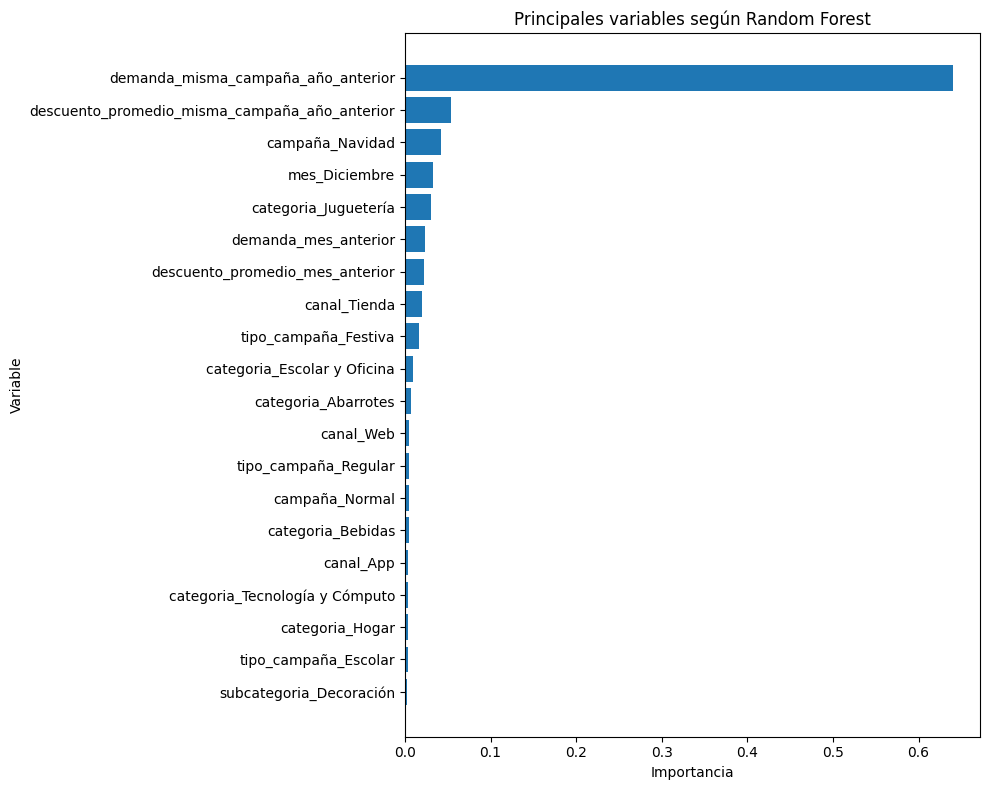

In [ ]:
#@title Gráfico de importancia de variables

top_importancia = (
    df_importancia_variables
    .head(20)
    .sort_values(by="importancia", ascending=True)
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_importancia["variable"],
    top_importancia["importancia"]
)

plt.title("Principales variables según Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [ ]:
#@title Importancia agrupada por variable original

def identificar_variable_original(nombre_variable):

    if nombre_variable in variables_numericas:
        return nombre_variable

    for variable in sorted(
        variables_categoricas,
        key=len,
        reverse=True
    ):
        if nombre_variable.startswith(f"{variable}_"):
            return variable

    return nombre_variable


df_importancia_variables["variable_original"] = (
    df_importancia_variables["variable"]
    .apply(identificar_variable_original)
)

df_importancia_agrupada = (
    df_importancia_variables
    .groupby("variable_original", as_index=False)["importancia"]
    .sum()
    .sort_values(by="importancia", ascending=False)
    .reset_index(drop=True)
)

df_importancia_agrupada["importancia_porcentaje"] = (
    df_importancia_agrupada["importancia"]
    / df_importancia_agrupada["importancia"].sum()
    * 100
)

display(df_importancia_agrupada)

,variable_original,importancia,importancia_porcentaje
0,demanda_misma_campaña_año_anterior,0.639776,63.977598
1,categoria,0.066726,6.672597
2,campaña,0.054564,5.456432
3,descuento_promedio_misma_campaña_año_anterior,0.053304,5.330379
4,mes,0.042285,4.228461
5,subcategoria,0.030857,3.085718
6,tipo_campaña,0.029300,2.930025
7,canal,0.028622,2.862187
8,demanda_mes_anterior,0.023539,2.353939
9,descuento_promedio_mes_anterior,0.022247,2.224737


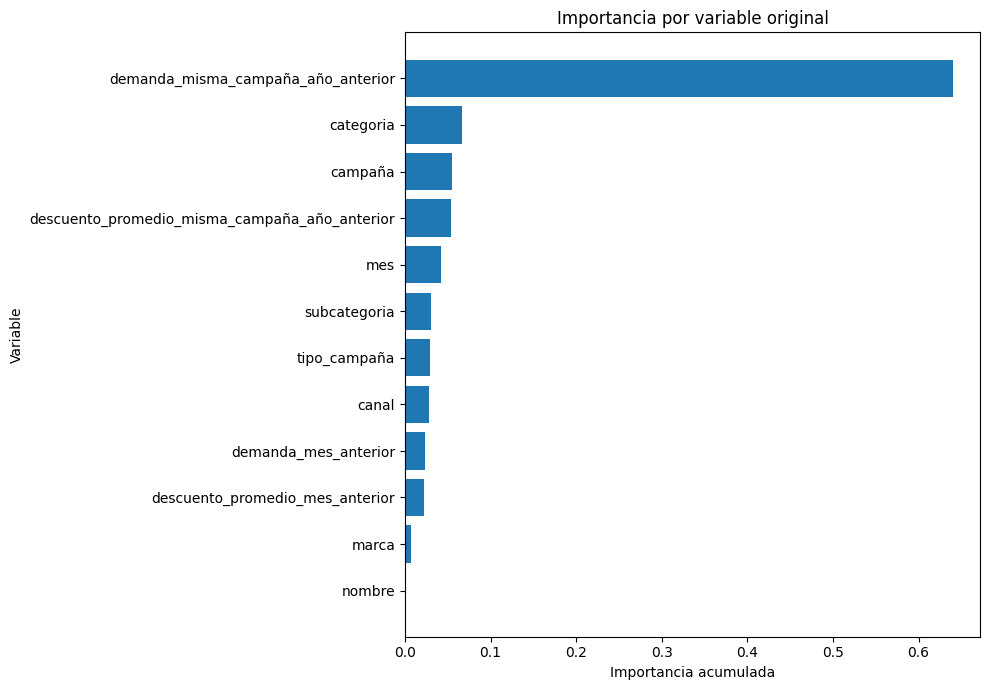

In [ ]:
#@title Gráfico de importancia agrupada

df_grafico_agrupado = (
    df_importancia_agrupada
    .sort_values(by="importancia", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    df_grafico_agrupado["variable_original"],
    df_grafico_agrupado["importancia"]
)

plt.title("Importancia por variable original")
plt.xlabel("Importancia acumulada")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### 💠 SHAP

In [ ]:
#@title Preparación de muestra para SHAP
import shap

from scipy import sparse

TAMANO_MUESTRA_SHAP = min(500, len(X_prueba))

X_muestra_shap = X_prueba.sample(
    n=TAMANO_MUESTRA_SHAP,
    random_state=SEMILLA
)

# Aplicar el mismo preprocesamiento utilizado por el modelo
X_muestra_transformada = preprocesador_final.transform(
    X_muestra_shap
)

# SHAP trabajará con una muestra densa manejable
if sparse.issparse(X_muestra_transformada):
    X_muestra_transformada = X_muestra_transformada.toarray()

df_X_muestra_shap = pd.DataFrame(
    X_muestra_transformada,
    columns=nombres_variables_transformadas,
    index=X_muestra_shap.index
)

print("Muestra utilizada:", df_X_muestra_shap.shape)

display(df_X_muestra_shap.head())

Muestra utilizada: (500, 1135)


,demanda_mes_anterior,demanda_misma_campaña_año_anterior,descuento_promedio_mes_anterior,descuento_promedio_misma_campaña_año_anterior,nombre_Accesorios Ayni 016,nombre_Accesorios Ayni 622,nombre_Accesorios CostaSur 424,nombre_Accesorios InkaHome 105,nombre_Accesorios Nativa 118,nombre_Aceite Altura 560,...,mes_Diciembre,mes_Enero,mes_Febrero,mes_Julio,mes_Junio,mes_Marzo,mes_Mayo,mes_Noviembre,mes_Octubre,mes_Septiembre
29053,-0.562238,0.453161,-1.167302,0.914515,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38217,0.021548,1.972838,1.697205,0.423800,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49946,-0.562238,0.127516,-1.167302,1.368635,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
40104,0.021548,-0.306677,-0.233060,0.415482,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
48179,-0.464940,0.236065,1.146771,0.699931,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
#@title Cálculo de valores SHAP

explicador_shap = shap.TreeExplainer(
    modelo_final
)

valores_shap = explicador_shap(
    df_X_muestra_shap
)

print("Valores SHAP calculados.")
print("Dimensión:", valores_shap.values.shape)

Valores SHAP calculados.
Dimensión: (500, 1135)


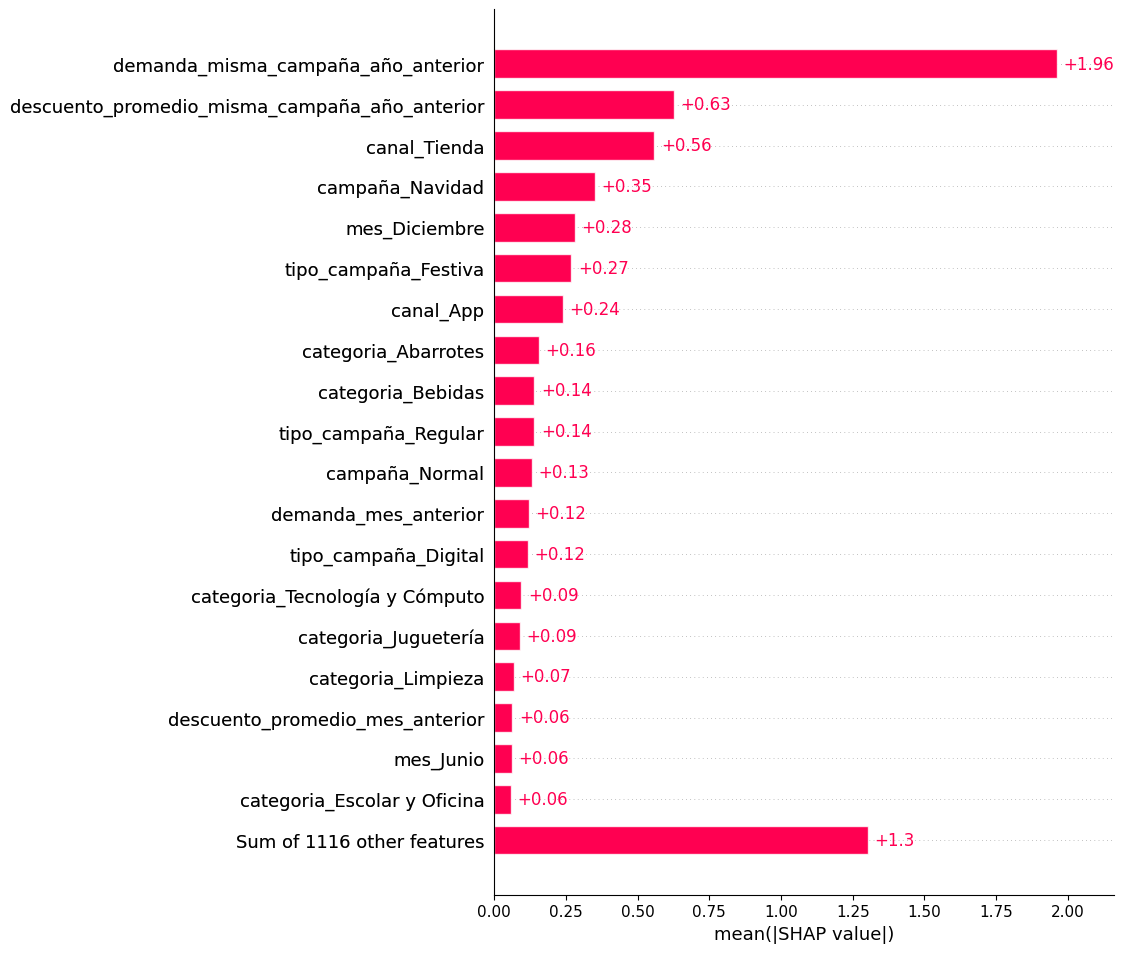

In [ ]:
#@title Importancia global mediante SHAP

shap.plots.bar(
    valores_shap,
    max_display=20
)

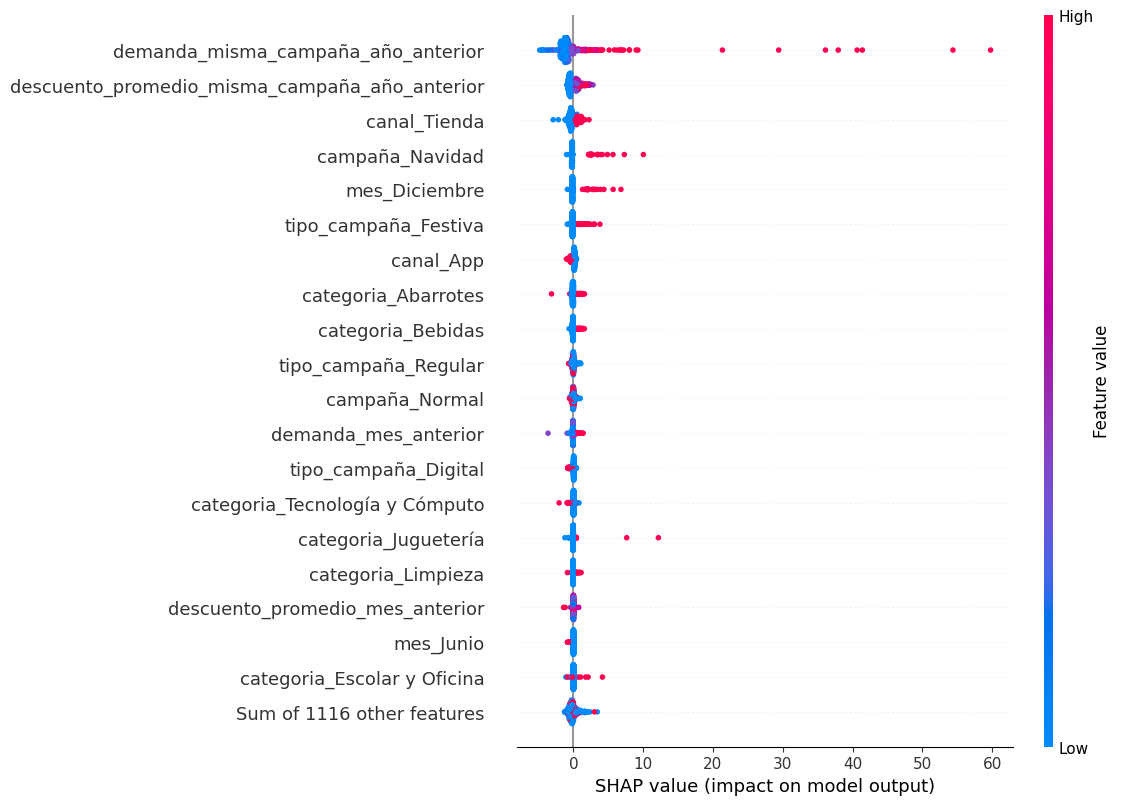

In [ ]:
#@title Impacto y dirección de variables mediante SHAP

shap.plots.beeswarm(
    valores_shap,
    max_display=20
)

In [ ]:
#@title Importancia SHAP agrupada por variable original

matriz_valores_shap = valores_shap.values

if matriz_valores_shap.ndim == 3:
    matriz_valores_shap = matriz_valores_shap[:, :, 0]

grupos_variables = {}

for posicion, nombre_variable in enumerate(nombres_variables_transformadas):

    variable_original = identificar_variable_original(
        nombre_variable
    )

    grupos_variables.setdefault(
        variable_original,
        []
    ).append(posicion)


importancias_shap_agrupadas = []

for variable_original, posiciones in grupos_variables.items():

    # Contribución conjunta de las columnas pertenecientes a una variable
    contribucion_variable = (
        matriz_valores_shap[:, posiciones]
        .sum(axis=1)
    )

    impacto_promedio = np.abs(
        contribucion_variable
    ).mean()

    importancias_shap_agrupadas.append({
        "variable": variable_original,
        "impacto_SHAP_promedio": impacto_promedio
    })


df_importancia_shap_agrupada = (
    pd.DataFrame(importancias_shap_agrupadas)
    .sort_values(
        by="impacto_SHAP_promedio",
        ascending=False
    )
    .reset_index(drop=True)
)

df_importancia_shap_agrupada["importancia_porcentaje"] = (
    df_importancia_shap_agrupada["impacto_SHAP_promedio"]
    / df_importancia_shap_agrupada["impacto_SHAP_promedio"].sum()
    * 100
)

display(df_importancia_shap_agrupada)

,variable,impacto_SHAP_promedio,importancia_porcentaje
0,demanda_misma_campaña_año_anterior,1.960694,36.294480
1,canal,0.725889,13.436951
2,descuento_promedio_misma_campaña_año_anterior,0.627119,11.608620
3,campaña,0.462652,8.564165
4,tipo_campaña,0.436885,8.087199
5,categoria,0.435782,8.066785
6,mes,0.332788,6.160254
7,subcategoria,0.179295,3.318944
8,demanda_mes_anterior,0.121610,2.251122
9,descuento_promedio_mes_anterior,0.062715,1.160925


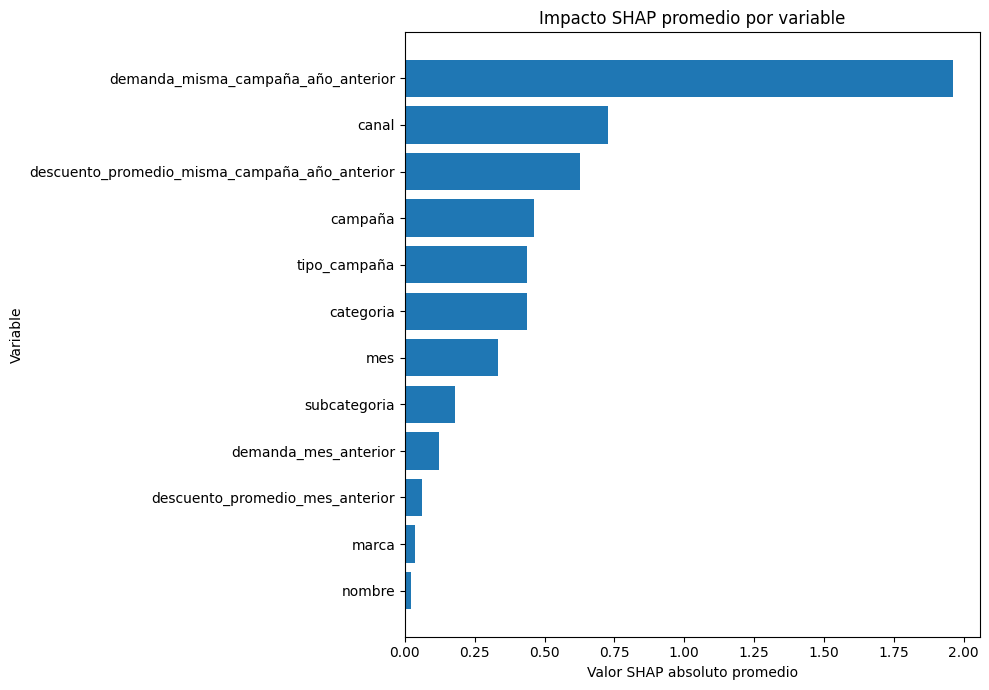

In [ ]:
#@title Gráfico SHAP por variable original

df_grafico_shap = (
    df_importancia_shap_agrupada
    .sort_values(
        by="impacto_SHAP_promedio",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    df_grafico_shap["variable"],
    df_grafico_shap["impacto_SHAP_promedio"]
)

plt.title("Impacto SHAP promedio por variable")
plt.xlabel("Valor SHAP absoluto promedio")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


Índice de la observación: 29053
Demanda real: 1.0
Demanda predicha: 2.867


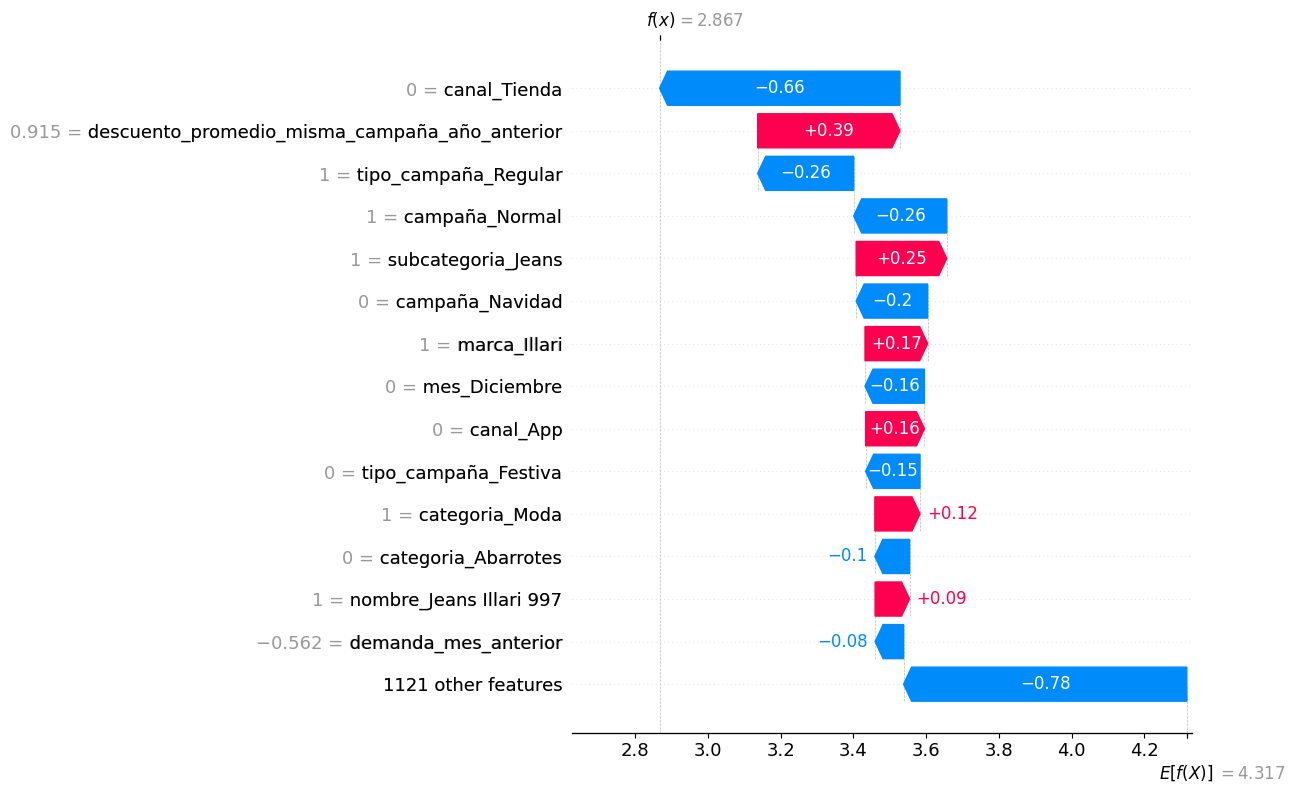

In [ ]:
#@title Explicación SHAP de una predicción individual

posicion_observacion = 0
indice_observacion = df_X_muestra_shap.index[posicion_observacion]

prediccion_observacion = modelo_final.predict(
    df_X_muestra_shap.iloc[[posicion_observacion]]
)[0]

demanda_real_observacion = y_prueba.loc[
    indice_observacion
]

print("Índice de la observación:", indice_observacion)
print("Demanda real:", demanda_real_observacion)
print("Demanda predicha:", round(prediccion_observacion, 4))

shap.plots.waterfall(
    valores_shap[posicion_observacion],
    max_display=15
)

In [ ]:
#@title Guardar resultados de importancia

from pathlib import Path

# Crear carpeta de salida
RUTA_ANALISIS_VARIABLES = Path(
    "/content/notebook03/análisis_variables"
)

RUTA_ANALISIS_VARIABLES.mkdir(
    parents=True,
    exist_ok=True
)

# Guardar archivos
df_importancia_variables.to_csv(
    RUTA_ANALISIS_VARIABLES / "importancia_detallada_random_forest.csv",
    index=False,
    encoding="utf-8-sig"
)

df_importancia_agrupada.to_csv(
    RUTA_ANALISIS_VARIABLES / "importancia_agrupada_random_forest.csv",
    index=False,
    encoding="utf-8-sig"
)

df_importancia_shap_agrupada.to_csv(
    RUTA_ANALISIS_VARIABLES / "importancia_shap_agrupada_random_forest.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Resultados guardados correctamente en:")
print(RUTA_ANALISIS_VARIABLES)

for archivo in RUTA_ANALISIS_VARIABLES.iterdir():
    print("-", archivo.name)

Resultados guardados correctamente en:
/content/notebook03/análisis_variables
- importancia_detallada_random_forest.csv
- importancia_shap_agrupada_random_forest.csv
- importancia_agrupada_random_forest.csv


**Interpretación**

El análisis de importancia de variables y valores SHAP mostró que la demanda registrada durante la misma campaña del año anterior fue el principal factor utilizado por Random Forest para estimar las ventas futuras. Asimismo, el canal de venta, los descuentos históricos, la campaña, el mes y la categoría del producto presentaron una influencia relevante sobre las predicciones. Estos resultados indican que la planificación de inventarios debe apoyarse principalmente en campañas comparables del año anterior, pero ajustando las cantidades según las condiciones comerciales y el canal en el que se espera realizar la venta. El modelo también evidenció que las campañas festivas, especialmente Navidad y diciembre, tienden a incrementar la demanda estimada, mientras que los periodos regulares presentan niveles más moderados.

## 🚩 Conclusiones y recomendaciones

**Conclusiones**

1. Los resultados muestran que Random Forest fue el modelo con mejor desempeño general. Alcanzó un MAE de 3.18 unidades, un RMSE de 5.22 y un R^2 de 0.7089 en el conjunto de prueba, por lo que logró estimar la demanda con mayor precisión que los demás modelos evaluados.

2. El modelo Random Forest logró explicar aproximadamente el 70.89 % de la variación observada en la demanda de 2025. Esto indica que las características del producto, la campaña, el canal de venta y el comportamiento histórico contienen información relevante para anticipar las unidades que podrían venderse.

3. El error promedio de aproximadamente 3.18 unidades representa un resultado favorable para la planificación comercial. Aunque no todas las predicciones serán exactas, el modelo puede servir como una referencia útil para estimar la cantidad de productos que deberían estar disponibles durante cada campaña y periodo.

4. XGBoost también presentó un desempeño competitivo, con un MAE de 3.25 y un R^2 de 0.6952. Sin embargo, Random Forest obtuvo mejores resultados tanto en la validación cruzada como en la prueba final, lo que respalda su selección como modelo principal.

5. Ridge Regression obtuvo el rendimiento más bajo y generó 457 predicciones negativas, las cuales no tienen una interpretación válida en términos de unidades vendidas. Este resultado demuestra que una relación únicamente lineal no representa por completo el comportamiento de la demanda, mientras que los modelos basados en árboles capturan mejor sus patrones.

**Recomendaciones**

1. Se recomienda utilizar Random Forest como modelo principal para apoyar la planificación de inventarios, debido a que presentó el menor error y la mayor capacidad para explicar la demanda en el conjunto de prueba.

2. Las predicciones deberían emplearse como una herramienta de apoyo y no como una cantidad definitiva de abastecimiento. La empresa puede complementar los resultados con el criterio del área comercial, el stock disponible, los tiempos de reposición y las condiciones particulares de cada campaña.

3. Se recomienda prestar mayor atención a los productos o periodos en los que el error sea considerablemente superior al promedio. El análisis de estos casos puede ayudar a identificar campañas atípicas, cambios inesperados en el comportamiento de los clientes o productos con una demanda especialmente variable.

4. El modelo debería actualizarse de manera periódica con nuevas ventas. A medida que se incorporen datos de campañas y periodos recientes, será posible adaptar las predicciones a cambios en las preferencias de los clientes, el crecimiento de los canales digitales y las nuevas condiciones comerciales.

5. Se recomienda complementar las métricas predictivas con el análisis de importancia de variables y valores SHAP. Esto permitirá comprender qué productos, campañas, canales, meses y antecedentes históricos influyen más en las estimaciones, facilitando decisiones de inventario y promociones más justificadas.